# 🍇 Grape Image Cleaning and Preprocessing

## Project: Apollo AgriVerse

This notebook performs image cleaning and preprocessing for the Grape crop dataset.

### Grape Growth Stages

1. Bud Burst
2. Vegetative
3. Flowering
4. Fruit Development
5. Harvest

### Processing Pipeline

Raw Images
→ Image Cleaning
→ Cleaned Images
→ Image Preprocessing
→ Preprocessed Images

### Dataset Location

`D:\Apollo_AgriVerse\03_Images\Dataset\Crop_Images\Grapes`

In [3]:
import os
import shutil
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [4]:
from pathlib import Path

# ============================================================
# DATASET PATH
# ============================================================

BASE_DIR = Path(
    r"D:\Apollo_AgriVerse\03_Images\Dataset\Crop_Images\Grapes"
)

# ============================================================
# GROWTH STAGES
# ============================================================

STAGES = [
    "01_Bud_Burst",
    "02_Vegetative",
    "03_Flowering",
    "04_Fruit_Development",
    "05_Harvest"
]

# ============================================================
# CHECK DATASET
# ============================================================

print("Grape Dataset Path:")
print(BASE_DIR)

print("\nPath exists:", BASE_DIR.exists())

print("\nGrowth Stage Folders:")
for stage in STAGES:
    stage_path = BASE_DIR / stage
    print(f"{stage}: {stage_path.exists()}")

Grape Dataset Path:
D:\Apollo_AgriVerse\03_Images\Dataset\Crop_Images\Grapes

Path exists: True

Growth Stage Folders:
01_Bud_Burst: True
02_Vegetative: True
03_Flowering: True
04_Fruit_Development: True
05_Harvest: True


# Step 2 — Inspect Raw Grape Images

In this step, we will:

- Count images in each growth stage.
- Check which image file formats are present.
- Calculate the total number of raw images.

This helps us understand the dataset before cleaning.

In [5]:
# ============================================================
# IMAGE INSPECTION
# ============================================================

# Supported image formats
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

total_images = 0

print("=" * 60)
print("RAW GRAPE DATASET IMAGE COUNT")
print("=" * 60)

for stage in STAGES:
    stage_path = BASE_DIR / stage

    # Find image files
    images = [
        file for file in stage_path.iterdir()
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    count = len(images)
    total_images += count

    print(f"{stage:<25} : {count} images")

print("=" * 60)
print(f"{'TOTAL':<25} : {total_images} images")
print("=" * 60)

RAW GRAPE DATASET IMAGE COUNT
01_Bud_Burst              : 29 images
02_Vegetative             : 29 images
03_Flowering              : 46 images
04_Fruit_Development      : 36 images
05_Harvest                : 30 images
TOTAL                     : 170 images


# Step 3 — Create Output Folders

We will create two separate folders:

### 1. Grape_Cleaned
Stores images after cleaning.

Cleaning will remove:
- Corrupted images
- Images that cannot be opened
- Invalid image files

### 2. Grape_Preprocessed
Stores images after preprocessing.

Preprocessing will prepare valid images for the machine learning model.

The original raw dataset will remain unchanged.

In [7]:
# ============================================================
# CREATE CLEANED AND PREPROCESSED DIRECTORIES
# ============================================================

CLEANED_DIR = BASE_DIR / "Grape_Cleaned"
PREPROCESSED_DIR = BASE_DIR / "Grape_Preprocessed"

# Create stage folders inside Grape_Cleaned
for stage in STAGES:
    (CLEANED_DIR / stage).mkdir(parents=True, exist_ok=True)

# Create stage folders inside Grape_Preprocessed
for stage in STAGES:
    (PREPROCESSED_DIR / stage).mkdir(parents=True, exist_ok=True)

print("Folders created successfully!")
print()

print("Cleaned Dataset:")
print(CLEANED_DIR)

print("\nPreprocessed Dataset:")
print(PREPROCESSED_DIR)

print("\nFolder structure:")
for stage in STAGES:
    print(f"  {stage}")

Folders created successfully!

Cleaned Dataset:
D:\Apollo_AgriVerse\03_Images\Dataset\Crop_Images\Grapes\Grape_Cleaned

Preprocessed Dataset:
D:\Apollo_AgriVerse\03_Images\Dataset\Crop_Images\Grapes\Grape_Preprocessed

Folder structure:
  01_Bud_Burst
  02_Vegetative
  03_Flowering
  04_Fruit_Development
  05_Harvest


# Step 4 — Detect Corrupted Images

In this step, every raw grape image will be checked to determine whether it can be opened correctly.

A corrupted image may:
- Fail to open.
- Be incomplete.
- Have invalid image data.
- Cause an error during model training.

In [8]:
# ============================================================
# CHECK FOR CORRUPTED IMAGES
# ============================================================

from PIL import Image

corrupted_images = []
valid_images = []

print("=" * 60)
print("CHECKING IMAGE INTEGRITY")
print("=" * 60)

for stage in STAGES:

    stage_path = BASE_DIR / stage

    print(f"\nChecking: {stage}")

    for image_path in stage_path.iterdir():

        # Only process supported image files
        if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:

            try:
                # Open image
                with Image.open(image_path) as img:
                    img.verify()

                valid_images.append(image_path)

            except Exception as e:
                corrupted_images.append({
                    "stage": stage,
                    "file": str(image_path),
                    "error": str(e)
                })

print("\n" + "=" * 60)
print("IMAGE INTEGRITY RESULTS")
print("=" * 60)

print(f"Valid images     : {len(valid_images)}")
print(f"Corrupted images : {len(corrupted_images)}")
print(f"Total checked    : {len(valid_images) + len(corrupted_images)}")

CHECKING IMAGE INTEGRITY

Checking: 01_Bud_Burst

Checking: 02_Vegetative

Checking: 03_Flowering

Checking: 04_Fruit_Development

Checking: 05_Harvest

IMAGE INTEGRITY RESULTS
Valid images     : 170
Corrupted images : 0
Total checked    : 170


In [9]:
# ============================================================
# DISPLAY CORRUPTED IMAGE LIST
# ============================================================

if corrupted_images:

    print("\nCorrupted Images:")
    print("-" * 60)

    for item in corrupted_images:
        print(f"Stage : {item['stage']}")
        print(f"File  : {item['file']}")
        print(f"Error : {item['error']}")
        print("-" * 60)

else:
    print("\nNo corrupted images found.")


No corrupted images found.


# Step 5 — Image Cleaning

The raw grape images are cleaned before preprocessing.

Cleaning operations:
- Check image integrity
- Remove corrupted/unreadable images
- Convert images to RGB format
- Remove extremely small images
- Save cleaned images in `Grape_Cleaned`

The original dataset is not modified.

In [10]:
# ============================================================
# IMAGE CLEANING
# ============================================================

from PIL import Image

MIN_WIDTH = 100
MIN_HEIGHT = 100

cleaned_count = 0
skipped_count = 0

for stage in STAGES:

    source_dir = BASE_DIR / stage
    output_dir = CLEANED_DIR / stage

    print(f"\nCleaning: {stage}")

    for image_path in source_dir.iterdir():

        if not image_path.is_file():
            continue

        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        try:
            with Image.open(image_path) as img:

                # Verify image
                img.verify()

            # Reopen after verify
            with Image.open(image_path) as img:

                width, height = img.size

                # Skip very small images
                if width < MIN_WIDTH or height < MIN_HEIGHT:
                    skipped_count += 1
                    continue

                # Convert to RGB
                img = img.convert("RGB")

                # Save as JPG
                output_path = output_dir / f"{image_path.stem}.jpg"

                img.save(
                    output_path,
                    "JPEG",
                    quality=95
                )

                cleaned_count += 1

        except Exception:
            skipped_count += 1

print("\n" + "=" * 60)
print("CLEANING COMPLETED")
print("=" * 60)
print("Cleaned images :", cleaned_count)
print("Skipped images :", skipped_count)
print("Saved in       :", CLEANED_DIR)


Cleaning: 01_Bud_Burst

Cleaning: 02_Vegetative

Cleaning: 03_Flowering

Cleaning: 04_Fruit_Development

Cleaning: 05_Harvest

CLEANING COMPLETED
Cleaned images : 170
Skipped images : 0
Saved in       : D:\Apollo_AgriVerse\03_Images\Dataset\Crop_Images\Grapes\Grape_Cleaned


# Step 6 — Image Preprocessing

The cleaned images are resized to 224 × 224 pixels.

Preprocessing operations:
- Resize images to 224 × 224
- Convert to RGB
- Save as JPEG
- Preserve the growth-stage folder structure

Output:
`Grape_Preprocessed`

In [11]:
# ============================================================
# IMAGE PREPROCESSING
# ============================================================

from PIL import Image

IMG_SIZE = (224, 224)

preprocessed_count = 0

for stage in STAGES:

    source_dir = CLEANED_DIR / stage
    output_dir = PREPROCESSED_DIR / stage

    print(f"\nPreprocessing: {stage}")

    for image_path in source_dir.iterdir():

        if not image_path.is_file():
            continue

        try:
            with Image.open(image_path) as img:

                # Convert to RGB
                img = img.convert("RGB")

                # Resize
                img = img.resize(
                    IMG_SIZE,
                    Image.Resampling.LANCZOS
                )

                # Save
                output_path = output_dir / image_path.name

                img.save(
                    output_path,
                    "JPEG",
                    quality=95
                )

                preprocessed_count += 1

        except Exception as e:
            print(f"Skipped: {image_path.name} | {e}")

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETED")
print("=" * 60)
print("Preprocessed images :", preprocessed_count)
print("Image size          :", IMG_SIZE)
print("Saved in            :", PREPROCESSED_DIR)


Preprocessing: 01_Bud_Burst

Preprocessing: 02_Vegetative

Preprocessing: 03_Flowering

Preprocessing: 04_Fruit_Development

Preprocessing: 05_Harvest

PREPROCESSING COMPLETED
Preprocessed images : 170
Image size          : (224, 224)
Saved in            : D:\Apollo_AgriVerse\03_Images\Dataset\Crop_Images\Grapes\Grape_Preprocessed


# Step 7 — Verify Cleaned and Preprocessed Dataset

We verify the number of images available in each growth stage after cleaning and preprocessing.

In [12]:
# ============================================================
# FINAL DATASET VERIFICATION
# ============================================================

print("=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)

for stage in STAGES:

    cleaned_files = list(
        (CLEANED_DIR / stage).glob("*.jpg")
    )

    preprocessed_files = list(
        (PREPROCESSED_DIR / stage).glob("*.jpg")
    )

    print(f"\n{stage}")
    print(f"  Cleaned       : {len(cleaned_files)}")
    print(f"  Preprocessed  : {len(preprocessed_files)}")

print("\n" + "=" * 70)
print("DATASET PROCESSING COMPLETE")
print("=" * 70)

FINAL DATASET SUMMARY

01_Bud_Burst
  Cleaned       : 29
  Preprocessed  : 29

02_Vegetative
  Cleaned       : 29
  Preprocessed  : 29

03_Flowering
  Cleaned       : 46
  Preprocessed  : 46

04_Fruit_Development
  Cleaned       : 36
  Preprocessed  : 36

05_Harvest
  Cleaned       : 30
  Preprocessed  : 30

DATASET PROCESSING COMPLETE


# Step 8 — Verify Preprocessed Image Dimensions

All preprocessed images should have the dimensions:

**224 × 224 × 3**

where:
- 224 = width
- 224 = height
- 3 = RGB channels

In [13]:
# ============================================================
# VERIFY PREPROCESSED IMAGE SIZE
# ============================================================

checked = 0
incorrect = 0

for stage in STAGES:

    folder = PREPROCESSED_DIR / stage

    for image_path in folder.glob("*.jpg"):

        try:
            with Image.open(image_path) as img:

                if img.size != IMG_SIZE or img.mode != "RGB":
                    incorrect += 1
                else:
                    checked += 1

        except Exception:
            incorrect += 1

print("=" * 60)
print("PREPROCESSING VERIFICATION")
print("=" * 60)

print("Correct images   :", checked)
print("Incorrect images :", incorrect)

if incorrect == 0:
    print("\nSUCCESS: All images are 224 × 224 RGB.")
else:
    print("\nWARNING: Some images need checking.")

PREPROCESSING VERIFICATION
Correct images   : 170
Incorrect images : 0

SUCCESS: All images are 224 × 224 RGB.


# Step 9 — Visual Quality Check

This step compares images before and after processing.

We will check:

- Original raw image
- Cleaned image
- Preprocessed image

The purpose is to make sure that:
- Images are not corrupted.
- Cleaning did not damage the image.
- Preprocessing resized the image correctly.
- The growth-stage labels are preserved.

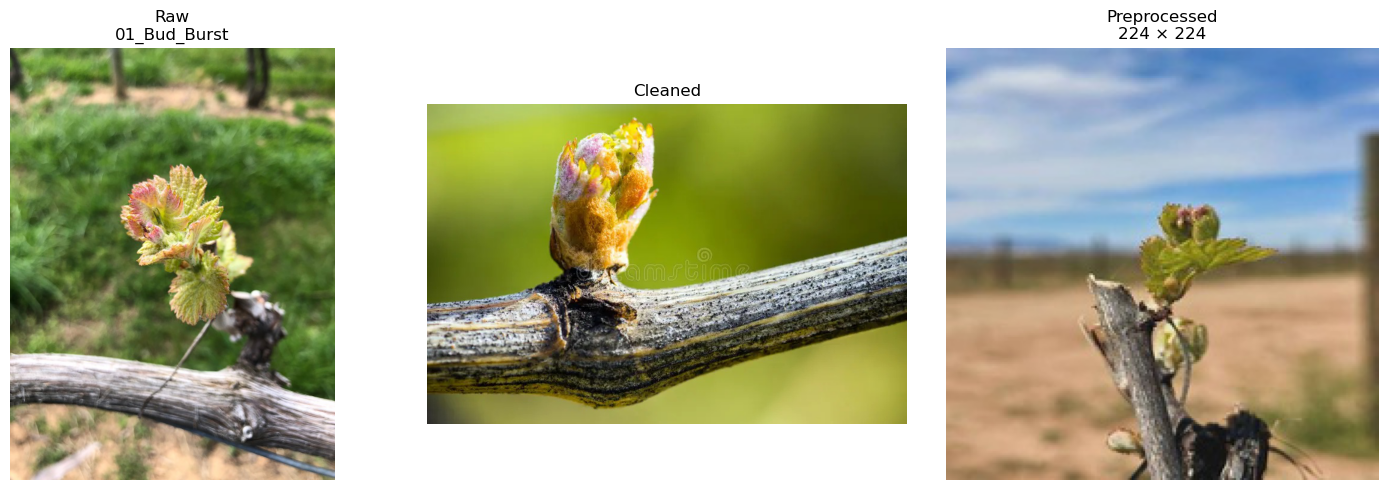

Stage: 01_Bud_Burst
Raw size: (624, 832)
Cleaned size: (800, 533)
Preprocessed size: (224, 224)


In [14]:
# ============================================================
# VISUALIZE RAW, CLEANED AND PREPROCESSED IMAGES
# ============================================================

import random
import matplotlib.pyplot as plt
from PIL import Image

# Select one stage
stage = random.choice(STAGES)

# Get images
raw_images = [
    p for p in (BASE_DIR / stage).iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

cleaned_images = list((CLEANED_DIR / stage).glob("*.jpg"))
preprocessed_images = list((PREPROCESSED_DIR / stage).glob("*.jpg"))

# Make sure images exist
if raw_images and cleaned_images and preprocessed_images:

    raw_path = random.choice(raw_images)
    cleaned_path = random.choice(cleaned_images)
    preprocessed_path = random.choice(preprocessed_images)

    # Open images
    raw_img = Image.open(raw_path)
    cleaned_img = Image.open(cleaned_path)
    preprocessed_img = Image.open(preprocessed_path)

    # Display
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(raw_img)
    plt.title(f"Raw\n{stage}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cleaned_img)
    plt.title("Cleaned")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(preprocessed_img)
    plt.title("Preprocessed\n224 × 224")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Stage:", stage)
    print("Raw size:", raw_img.size)
    print("Cleaned size:", cleaned_img.size)
    print("Preprocessed size:", preprocessed_img.size)

else:
    print("Images are missing for this stage.")

# Step 10 — Grape Growth Stage Distribution

This step checks the number of preprocessed images available for each grape growth stage.

Growth stages:

1. Bud Burst
2. Vegetative
3. Flowering
4. Fruit Development
5. Harvest

A balanced dataset is useful for machine learning because one class should not contain far more images than the others.

In [15]:
# ============================================================
# CLASS DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

stage_counts = {}

for stage in STAGES:
    folder = PREPROCESSED_DIR / stage

    count = len([
        p for p in folder.glob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    stage_counts[stage] = count

print("=" * 60)
print("PREPROCESSED DATASET DISTRIBUTION")
print("=" * 60)

for stage, count in stage_counts.items():
    print(f"{stage:<25} : {count} images")

print("=" * 60)
print("Total images:", sum(stage_counts.values()))

PREPROCESSED DATASET DISTRIBUTION
01_Bud_Burst              : 29 images
02_Vegetative             : 29 images
03_Flowering              : 46 images
04_Fruit_Development      : 36 images
05_Harvest                : 30 images
Total images: 170


# Step 11 — Visualize Growth Stage Distribution

A bar chart is created to compare the number of images in each grape growth stage.

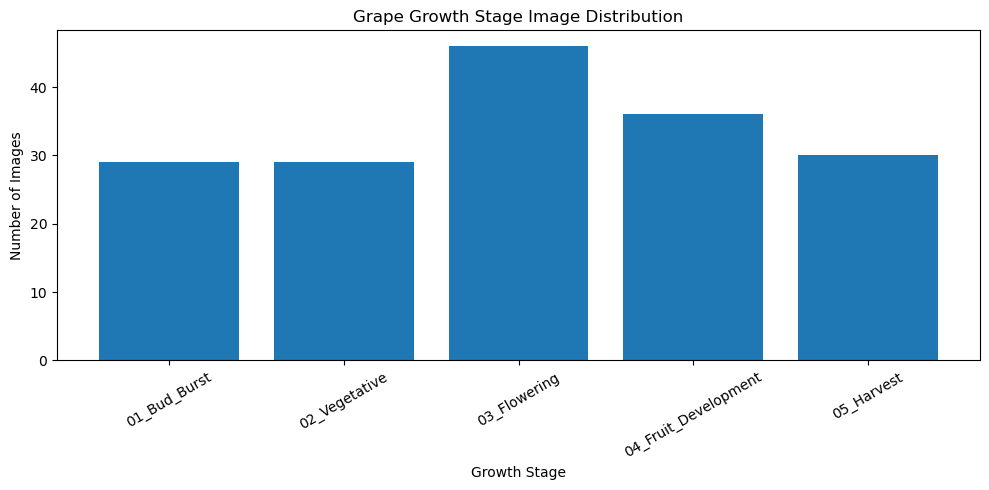

In [16]:
# ============================================================
# STAGE DISTRIBUTION CHART
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    stage_counts.keys(),
    stage_counts.values()
)

plt.title("Grape Growth Stage Image Distribution")
plt.xlabel("Growth Stage")
plt.ylabel("Number of Images")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [17]:
# ============================================================
# SAVE DATASET STATISTICS
# ============================================================

import pandas as pd

stats_df = pd.DataFrame({
    "Growth_Stage": list(stage_counts.keys()),
    "Image_Count": list(stage_counts.values())
})

stats_path = BASE_DIR / "Grape_Dataset_Statistics.csv"

stats_df.to_csv(stats_path, index=False)

print("Dataset statistics saved successfully!")
print()
print("File:")
print(stats_path)

print()
print(stats_df)

Dataset statistics saved successfully!

File:
D:\Apollo_AgriVerse\03_Images\Dataset\Crop_Images\Grapes\Grape_Dataset_Statistics.csv

           Growth_Stage  Image_Count
0          01_Bud_Burst           29
1         02_Vegetative           29
2          03_Flowering           46
3  04_Fruit_Development           36
4            05_Harvest           30
